# NOT training with GDmax and Extragradient

In [3]:
import os, sys
sys.path.append("..")

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import clear_output

import math
device = "cuda" if torch.cuda.is_available() else "cpu"

from src.models import Transport, Critic

In [2]:
# source distribution μ
def sample_mu(batch_size, device="cpu"):
    x = 2 * torch.rand(batch_size, 1, device=device) - 1  # [-1,1]
    y = torch.zeros(batch_size, 1, device=device)         # y = 0
    return torch.cat([x, y], dim=1)


# target distribution ν
def sample_nu(batch_size, device="cpu"):
    x = torch.zeros(batch_size, 1, device=device)         # y = 0
    y = 2 * torch.rand(batch_size, 1, device=device) - 1  # [-1,1]
    return torch.cat([x, y], dim=1)

In [3]:
mu = sample_mu(1000)
nu = sample_nu(1000)

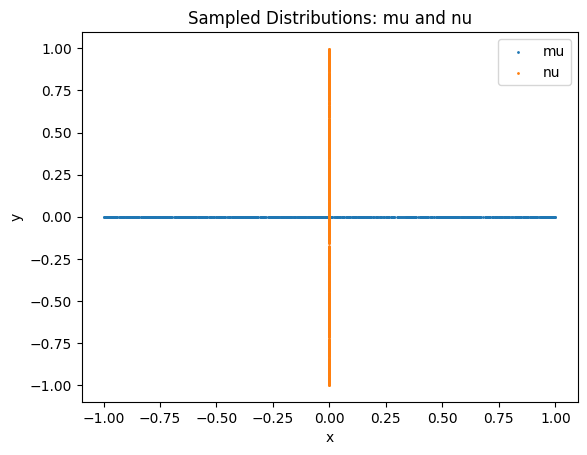

In [4]:
plt.figure()
plt.scatter(mu[:,0].numpy(), mu[:,1].numpy(), s=1, label="mu")
plt.scatter(nu[:,0].numpy(), nu[:,1].numpy(), s=1, label="nu")
plt.legend()
plt.title("Sampled Distributions: mu and nu")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [5]:
class Transport(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        z = torch.randn(x.shape[0], 1, device=x.device)
        return self.net(torch.cat([x, z], dim=1))


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
def cost(x, y):
    return ((x - y) ** 2).sum(dim=1, keepdim=True)/2

In [7]:
def show_mapping(T,sample_mu,sample_nu):
    x = sample_mu(1000).to(device)

    outputs = []
    for _ in range(5):
        outputs.append(T(x).detach().cpu())

    outputs = torch.cat(outputs, dim=0)
    x = x.cpu()
    y = sample_nu(1000).cpu()

    plt.figure()
    plt.scatter(x[:,0], x[:,1], label="mu", s=1, alpha=0.5)
    plt.scatter(y[:,0], y[:,1], label="nu", s=1, alpha=0.5)
    plt.scatter(outputs[:,0], outputs[:,1], label="T(x,z)", s=1, alpha=0.5)
    plt.axis('equal')
    plt.legend()
    plt.show()

In [8]:
def grad_norm(grads):
    return torch.sqrt(sum((g**2).sum() for g in grads))

def cosine_lr(step, total_steps, lr_max, lr_min=0.0):
    return lr_min + 0.5 * (lr_max - lr_min) * (
        1 + math.cos(math.pi * step / (step+total_steps))
    )

In [33]:
T = Transport().to(device)
f = Critic().to(device)

loss_hist = []
grad_T_hist = []
grad_f_hist = []

step 20000, loss 0.2870


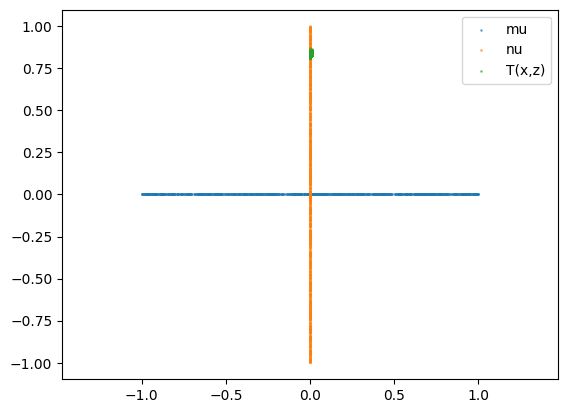

In [34]:
lr_T = 1e-4
lr_f = 1e-4

K = 10

optimizer_T = torch.optim.Adam(T.parameters(), lr=lr_T)
optimizer_f = torch.optim.Adam(f.parameters(), lr=lr_f, maximize= True)

batchsize_x = 1024
batchsize_y = 1024

for step in range(20000):
    x = sample_mu(batchsize_x).to(device)
    y = sample_nu(batchsize_y).to(device)

    for _ in range(K):
        Tx = T(x)
        loss = cost(x, Tx).mean() - f(Tx).mean() + f(y).mean()

        optimizer_T.zero_grad()
        loss.backward()
        optimizer_T.step()

    Tx = T(x)
    loss = cost(x, Tx).mean() - f(Tx).mean() + f(y).mean()

    optimizer_f.zero_grad()
    loss.backward()
    optimizer_f.step()

    Tx = T(x)
    loss = cost(x, Tx).mean() - f(Tx).mean() + f(y).mean()

    T_grads = torch.autograd.grad(loss, T.parameters(), retain_graph=True)
    f_grads = torch.autograd.grad(loss, f.parameters())

    grad_T = grad_norm(T_grads).item()
    grad_f = grad_norm(f_grads).item()

    loss_hist.append(loss.item())
    grad_T_hist.append(grad_T)
    grad_f_hist.append(grad_f)

    if (step+1) % 500 == 0:
        lr_T = cosine_lr(step, 4000, 1e-4, 0)
        lr_f = cosine_lr(step, 4000, 1e-4, 0)
        clear_output(wait=True)
        print(f"step {step+1}, loss {loss.item():.4f}")
        show_mapping(T, sample_mu, sample_nu)

step 100000, loss 0.3417


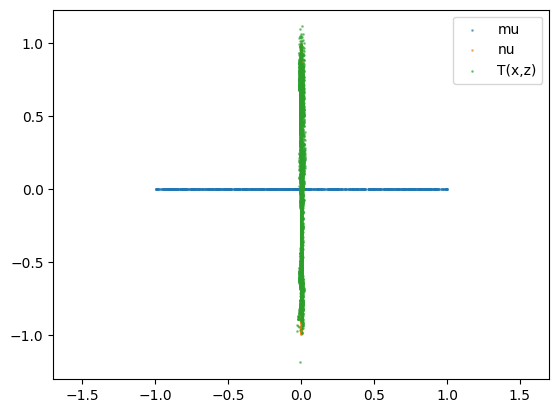

In [30]:
lr_T = 1e-3
lr_f = 1e-3

batchsize_x = 1024
batchsize_y = 1024
for step in range(100000):
    x = sample_mu(batchsize_x).to(device)
    y = sample_nu(batchsize_y).to(device)

    T_old = [p.clone() for p in T.parameters()]
    f_old = [p.clone() for p in f.parameters()]

    # -------- critic update (maximize) --------
    Tx = T(x)
    loss = cost(x, Tx).mean() - f(Tx).mean() + f(y).mean()
    T_gradient = torch.autograd.grad(loss, T.parameters(), create_graph=True)
    f_gradient = torch.autograd.grad(loss, f.parameters())

    with torch.no_grad():
        for p, g in zip(T.parameters(), T_gradient):
            p -= lr_T * g
        for p, g in zip(f.parameters(), f_gradient):
            p += lr_f * g
    Tx2 = T(x)
    loss2 = cost(x, Tx2).mean() - f(Tx2).mean() + f(y).mean()
    T_grad_true = torch.autograd.grad(loss2, T.parameters(), create_graph=True)
    f_grad_true = torch.autograd.grad(loss2, f.parameters())

    # ----- restore parameters -----
    with torch.no_grad():
        for p, p_old in zip(T.parameters(), T_old):
            p.copy_(p_old)
        for p, p_old in zip(f.parameters(), f_old):
            p.copy_(p_old)

    with torch.no_grad():
        for p, g in zip(T.parameters(), T_grad_true):
            p -= lr_T * g
        for p, g in zip(f.parameters(), f_grad_true):
            p += lr_f * g

    Tx = T(x)
    loss = cost(x, Tx).mean() - f(Tx).mean() + f(y).mean()

    T_grads = torch.autograd.grad(loss, T.parameters(), retain_graph=True)
    f_grads = torch.autograd.grad(loss, f.parameters())

    grad_T = grad_norm(T_grads).item()
    grad_f = grad_norm(f_grads).item()

    loss_hist.append(loss.item())
    grad_T_hist.append(grad_T)
    grad_f_hist.append(grad_f)

    if (step+1) % 500 == 0:
        lr_T = cosine_lr(step, 10000, 1e-3, 0)
        lr_f = cosine_lr(step, 10000, 1e-3, 0)

        clear_output(wait=True)
        print(f"step {step+1}, loss {loss.item():.4f}")
        show_mapping(T,sample_mu,sample_nu)

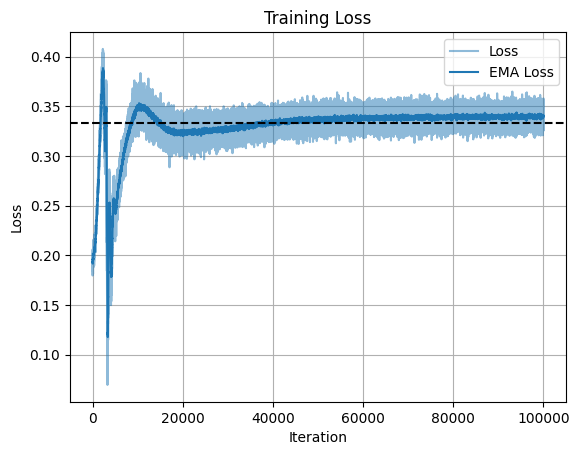

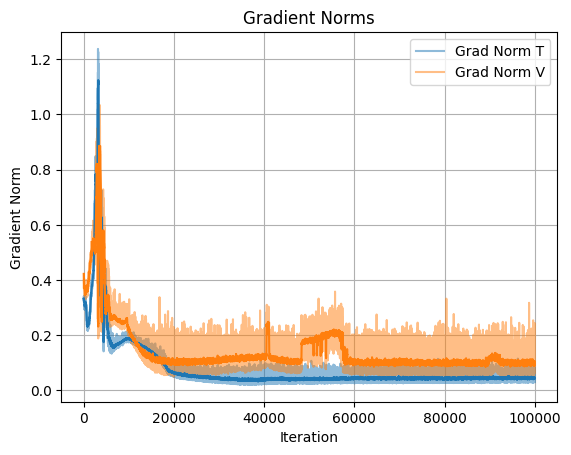

In [31]:
def ema_np(x, alpha=0.1):
    x = np.array(x)
    m = np.zeros_like(x, dtype=float)
    m[0] = x[0]
    for i in range(1, len(x)):
        m[i] = alpha * x[i] + (1 - alpha) * m[i-1]
    return m

def plot_loss(loss_hist):
    plt.figure()

    loss_plot = ema_np(loss_hist, alpha=0.05)

    plt.plot(loss_hist, label="Loss", color='tab:blue', alpha=0.5 )
    plt.plot(loss_plot, label="EMA Loss", color='tab:blue')
    plt.axhline(y=1/3, linestyle='--', color='black')

    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.legend()
    plt.grid(True)

    plt.show()

def plot_grad_norm(grad_T_hist, grad_f_hist):
    plt.figure()

    grad_T_plot = ema_np(grad_T_hist, alpha=0.05)
    grad_f_plot = ema_np(grad_f_hist, alpha=0.05)


    plt.plot(grad_T_hist, label="Grad Norm T", color='tab:blue', alpha=0.5 )
    plt.plot(grad_f_hist, label="Grad Norm V", color='tab:orange', alpha=0.5 )
    plt.plot(grad_T_plot, color='tab:blue')
    plt.plot(grad_f_plot, color='tab:orange')


    plt.xlabel("Iteration")
    plt.ylabel(r"Gradient Norm")
    plt.title("Gradient Norms")
    plt.legend()
    plt.grid(True)

    plt.show()

plot_loss(loss_hist)
plot_grad_norm(grad_T_hist, grad_f_hist)

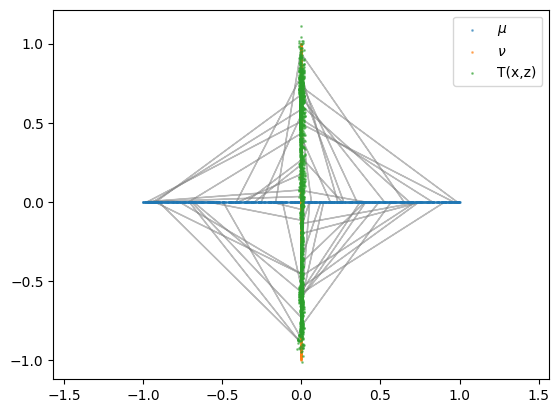

In [32]:
n_eval = 1000
x = sample_mu(n_eval).to(device)
option = True
outputs = []
for _ in range(2):
    outputs.append(T(x).detach().cpu())

outputs = torch.cat(outputs, dim=0)
x = x.cpu()
y = sample_nu(1000).cpu()

if (option == True):
    for i in range(50):
        plt.arrow(x[i,0], x[i,1],
              outputs[i,0]-x[i,0],
              outputs[i,1]-x[i,1],
              color='gray', alpha=0.5, head_width=0, length_includes_head=True)
    '''
    for i in range(50):
        plt.arrow(x[i,0], x[i,1],
              outputs[i+n_eval,0]-x[i,0],
              outputs[i+n_eval,1]-x[i,1],
              color='gray', alpha=0.5, head_width=0, length_includes_head=True)
    '''

plt.scatter(x[:,0], x[:,1], label=r"$\mu$", s=1, alpha=0.5)
plt.scatter(y[:,0], y[:,1], label=r"$\nu$", s=1, alpha=0.5)
plt.scatter(outputs[:,0], outputs[:,1], label="T(x,z)", s=1, alpha=0.5)
plt.axis('equal')
plt.legend()
# plt.title("Minimal NOT (stochastic, GDmax)")
plt.show()

In [ ]:
x = sample_mu(1).to(device)
outputs = []
for _ in range(50):
    outputs.append(T(x).detach().cpu())
outputs = torch.cat(outputs, dim=0)
x = x.cpu()
if (option == True):
    for i in range(50):
        plt.arrow(x[0,0], x[0,1],
              outputs[i,0]-x[0,0],
              outputs[i,1]-x[0,1],
              color='gray', alpha=0.5, head_width=0, length_includes_head=True)
plt.scatter(x[:,0], x[:,1], label="mu", s=1, alpha=0.5)
plt.scatter(y[:,0], y[:,1], label="nu", s=1, alpha=0.5)
plt.scatter(outputs[:,0], outputs[:,1], label="T(x,z)", s=1, alpha=0.5)
plt.axis('equal')
plt.legend()
# plt.title("Minimal NOT (stochastic, GDmax)")
plt.show()


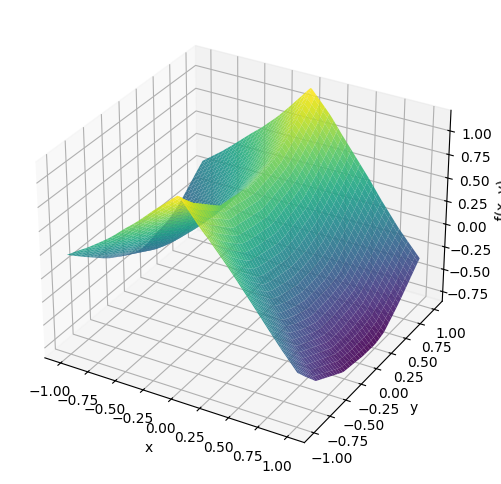

In [ ]:
# plot 범위
x_min, x_max = -1.0, 1.0
y_min, y_max = -1.0, 1.0

resolution = 200  # 클수록 부드러움
x = np.linspace(x_min, x_max, resolution)
y = np.linspace(y_min, y_max, resolution)
X, Y = np.meshgrid(x, y)

# (N^2, 2) 형태로 변환
XY = np.stack([X.ravel(), Y.ravel()], axis=1)
XY_torch = torch.tensor(XY, dtype=torch.float32, device = device)

with torch.no_grad():
    Z = f(XY_torch).cpu().numpy()

Z = Z.reshape(X.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    linewidth=0,
    antialiased=True,
    alpha=0.9
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
# ax.set_title(f'Potential $D$ at {nepo}k iters')

plt.show()